# Materi Informed Search

Bagaimana program mencari rute menuju tujuan? Pada perkuliahan ini, kita mempelajari
**Greedy Best-First Search** dan **A\*** melalui contoh graph, penelusuran langkah,
dan implementasi Python.

Setelah belajar, Anda diharapkan dapat:

- Menjelaskan heuristic serta perbedaan `g`, `h`, dan `f`.
- Mengimplementasikan Greedy dan A* dengan priority queue.
- Membaca frontier, merekonstruksi path, dan membandingkan hasil pencarian.
- Menjelaskan admissibility, consistency, dan pengaruh heuristic terhadap jumlah ekspansi.

Ikuti urutan **konsep → contoh → kode → hasil**. Sebelum menjalankan contoh,
prediksi node yang dipilih dan biaya path-nya, lalu cocokkan dengan output.
Jalankan cell dari atas ke bawah.

## 1. Mengenal Masalah Pencarian

Misalkan kita ingin pergi dari kota **S** ke kota **G**. Ada beberapa jalan,
dan setiap jalan memiliki biaya. Search mencari urutan jalan yang dapat mencapai G.

| Istilah | Contoh sederhana |
|---|---|
| State | Kota tempat kita berada |
| Start dan goal | Kota awal S dan tujuan G |
| Successor | Kota yang dapat dicapai dengan satu jalan |
| Step cost | Biaya satu jalan |
| Path | Urutan kota yang dilalui |
| Path cost | Jumlah biaya semua jalan pada path |
| Frontier | Kandidat yang masih menunggu untuk diperiksa |
| Explored / visited | State yang sudah diproses successor-nya |

State, start, goal, successor, dan biaya bersama-sama membentuk **search problem**.

### a. Uninformed dan informed search

**Uninformed search** tidak memakai estimasi sisa biaya menuju goal.

- **BFS:** memilih jumlah langkah paling sedikit terlebih dahulu.
- **DFS:** menelusuri satu cabang sedalam mungkin terlebih dahulu.
- **UCS:** memilih biaya yang sudah ditempuh paling kecil terlebih dahulu.

**Informed search** menambahkan perkiraan biaya yang masih diperlukan. Perkiraan ini
disebut **heuristic**. Greedy dan A* memakai heuristic dengan cara berbeda.

### b. Tiga nilai yang perlu diingat

Misalkan kita sudah menghabiskan biaya 4 untuk tiba di D dan memperkirakan
biaya dari D ke G sebesar 5.

| Nilai | Arti | Contoh di D |
|---|---|---:|
| `g(n)` | Biaya nyata dari start melalui path yang diketahui | 4 |
| `h(n)` | Estimasi biaya minimum yang masih diperlukan | 5 |
| `f(n)` pada A* | Estimasi total: `g(n) + h(n)` | 9 |

$$f(D)=4+5=9.$$

In [1]:
step_costs = [2, 2, 5]
current_g = sum(step_costs[:2])
heuristic_value = 5
print("Path S -> A -> D -> G, total cost:", sum(step_costs))
print("Di D: g =", current_g, ", h =", heuristic_value,
      ", f =", current_g + heuristic_value)

Path S -> A -> D -> G, total cost: 9
Di D: g = 4 , h = 5 , f = 9


**Perhatikan hasil:** biaya sampai D adalah 4, sedangkan estimasi sisa biaya adalah 5.
`g` berasal dari perjalanan yang diketahui; `h` masih berupa perkiraan.

**Coba pikirkan:** apakah path ke D yang pertama ditemukan pasti yang paling murah?

## 2. Menyiapkan Graph

Graph berikut memiliki 9 state. Kita mencari rute dari **S** ke **G**.

```text
S → A(2), B(4), C(3)
A → D(2), E(5)       B → F(2), D(1)       C → E(2), H(3)
D → G(5)            E → G(6)             F → G(9)       H → G(7)
```

Angka dalam kurung adalah biaya jalan. Graph ini **berarah**: `S → A` tidak berarti
tersedia jalan `A → S`.

Di Python, `("A", 2)` berarti “dapat menuju A dengan biaya 2”. Simpan graph dan
heuristic dalam dictionary terpisah.

In [2]:
graph = {
    "S": [("A", 2), ("B", 4), ("C", 3)],
    "A": [("D", 2), ("E", 5)],
    "B": [("F", 2), ("D", 1)],
    "C": [("E", 2), ("H", 3)],
    "D": [("G", 5)],
    "E": [("G", 6)],
    "F": [("G", 9)],
    "H": [("G", 7)],
    "G": [],
}

heuristic = {
    "S": 6, "A": 7, "B": 2, "C": 6,
    "D": 5, "E": 6, "F": 1, "H": 7, "G": 0,
}
start = "S"
goal = "G"

for state, successors in graph.items():
    print(f"{state}: successors={successors}, h={heuristic[state]}")

S: successors=[('A', 2), ('B', 4), ('C', 3)], h=6
A: successors=[('D', 2), ('E', 5)], h=7
B: successors=[('F', 2), ('D', 1)], h=2
C: successors=[('E', 2), ('H', 3)], h=6
D: successors=[('G', 5)], h=5
E: successors=[('G', 6)], h=6
F: successors=[('G', 9)], h=1
H: successors=[('G', 7)], h=7
G: successors=[], h=0


**Cara membaca data:**

- `graph["S"]` berisi jalan keluar dari S.
- `heuristic["B"] = 2` memperkirakan biaya **B menuju G**.
- Angka 2 tersebut bukan cost jalan S menuju B; cost jalan itu adalah 4.
- `graph["G"] = []` berarti G tidak memiliki successor.

**Coba hitung:** berapa biaya `S → A → D → G` dan `S → B → F → G`?

### a. Data yang dibutuhkan algoritma

Pisahkan data masalah dari fungsi pencarian. Dengan begitu, algoritma yang sama
dapat dijalankan pada graph berbeda dengan mengganti argumennya.

| Data | Bentuk pada contoh | Kegunaan |
|---|---|---|
| Graph | `graph[state]` | Daftar tetangga beserta biaya menuju masing-masing tetangga |
| Start | `start = "S"` | Titik awal pencarian |
| Goal | `goal = "G"` | Tujuan yang diperiksa dengan `state == goal` |
| Heuristic | `heuristic[state]` | Estimasi sisa biaya menuju goal |

Pada fungsi `greedy_search(problem, start, goal, heuristic)` dan
`a_star_search(problem, start, goal, heuristic)`, parameter `problem` menerima
dictionary `graph`. Karena itu, `problem[state]` dan `graph[state]` mengacu pada
daftar tetangga yang sama ketika fungsi dipanggil dengan data contoh.

### b. State, perpindahan, dan path

**State** adalah keadaan saat ini; **perpindahan** mengikuti satu edge pada graph.
Path `S → A → D → G` berisi 4 state dan 3 perpindahan.
Setiap pasangan `(next_state, step_cost)` menyatakan tujuan satu perpindahan
beserta biayanya.

Biaya path diperoleh dengan menjumlahkan biaya edge yang dilewati. Nilai heuristic
tidak ikut dijumlahkan ke biaya nyata path.

**Contoh bersama:** telusuri path berikut dan hitung total biayanya sebelum
menjalankan cell.

In [3]:
example_path = ["S", "A", "D", "G"]
example_total_cost = 0

for current_state, next_state in zip(example_path, example_path[1:]):
    neighbor_costs = dict(graph[current_state])
    step_cost = neighbor_costs[next_state]
    example_total_cost += step_cost
    print(f"{current_state} -> {next_state}: biaya {step_cost}")

print("Jumlah state:", len(example_path))
print("Jumlah perpindahan:", len(example_path) - 1)
print("Total biaya path:", example_total_cost)

S -> A: biaya 2
A -> D: biaya 2
D -> G: biaya 5
Jumlah state: 4
Jumlah perpindahan: 3
Total biaya path: 9


**Perhatikan hasil:** biaya path adalah `2 + 2 + 5 = 9`. `zip` memasangkan
setiap state dengan state setelahnya, lalu kode mengambil biaya edge dari graph.
Path contoh sudah ditentukan untuk latihan menghitung biaya; algoritma pencarian
akan menentukan path secara otomatis pada bagian berikutnya.

**Diskusi:** path `S → B → F → G` juga memiliki 3 perpindahan. Apakah biayanya sama?
Gunakan bobot edge untuk menjelaskan mengapa jumlah langkah saja belum cukup
untuk membandingkan dua rute.

## 3. Memahami Heuristic

Heuristic memperkirakan **biaya minimum yang masih diperlukan** untuk mencapai goal:

$$h(n)=\text{estimasi biaya dari state }n\text{ ke goal}.$$

Biaya dapat berupa jarak, waktu, atau energi. Satuan `h` harus sama dengan satuan `g`.

### a. Jarak garis lurus

Untuk rute kota, jarak garis lurus dapat menjadi estimasi jarak perjalanan.
Jalan sebenarnya mungkin memutar sehingga jaraknya lebih panjang.
Estimasi ini menjadi batas bawah jika biaya jalan adalah panjang jalan dan setiap
jalan setidaknya sepanjang garis lurus antara kedua ujungnya.

### b. Manhattan distance

Pada grid empat arah, hitung selisih horizontal ditambah selisih vertikal:

$$h(n)=|x_{current}-x_{goal}|+|y_{current}-y_{goal}|.$$

Contoh `(1,2)` ke `(4,6)`: `3 + 4 = 7` langkah.

In [4]:
def manhattan_distance(current, goal):
    current_x, current_y = current
    goal_x, goal_y = goal
    horizontal_distance = abs(current_x - goal_x)
    vertical_distance = abs(current_y - goal_y)
    return horizontal_distance + vertical_distance


print("Manhattan:", manhattan_distance((1, 2), (4, 6)))

Manhattan: 7


**Penjelasan kode:**

1. Fungsi menerima dua posisi: `current` dan `goal`.
2. Dua baris pertama memisahkan koordinat masing-masing posisi.
3. `abs(current_x - goal_x)` menghitung selisih horizontal tanpa tanda negatif.
4. `abs(current_y - goal_y)` menghitung selisih vertikal.
5. `return` menjumlahkan kedua selisih.

Hasil 7 belum memperhitungkan obstacle. Untuk gerakan empat arah berbiaya 1, obstacle
dapat membuat rute lebih panjang, tetapi tidak lebih pendek dari estimasi ini.
Jika biaya minimum per langkah adalah `m`, gunakan `m * Manhattan`.

### c. Euclidean distance

Euclidean menghitung jarak garis lurus pada bidang datar:

$$h(n)=\sqrt{(x_{current}-x_{goal})^2+(y_{current}-y_{goal})^2}.$$

Untuk `(1,2)` ke `(4,6)`, hasilnya $\sqrt{3^2+4^2}=5$.

In [5]:
import math


def euclidean_distance(current, goal):
    current_x, current_y = current
    goal_x, goal_y = goal
    horizontal_distance = current_x - goal_x
    vertical_distance = current_y - goal_y
    squared_distance = horizontal_distance ** 2 + vertical_distance ** 2
    return math.sqrt(squared_distance)


print("Euclidean:", euclidean_distance((1, 2), (4, 6)))

Euclidean: 5.0


**Perhatikan hasil:** Euclidean menghasilkan 5, sedangkan Manhattan menghasilkan 7.
Garis lurus lebih pendek karena bisa mengarah miring. Pada grid empat arah dengan
biaya 1, keduanya batas bawah, tetapi Manhattan memberikan perkiraan lebih dekat.

Kedua rumus tidak langsung berlaku untuk semua aturan gerakan. Misalnya, jika gerakan
diagonal berbiaya 1 diperbolehkan, Manhattan dapat melebih-lebihkan biaya.

### d. Null heuristic

Null heuristic selalu mengembalikan 0. Artinya, kita tidak memberikan petunjuk
tentang sisa biaya kepada algoritma.

Pada A*: $$f(n)=g(n)+0=g(n).$$

**A* dengan semua `h=0` menjadi UCS**, jika aturan tie dan duplicate sama.

In [6]:
def null_heuristic(state, goal=None):
    return 0


print("h(A) =", null_heuristic("A"))
print("Jika g(A)=4, priority A* =", 4 + null_heuristic("A"))

h(A) = 0
Jika g(A)=4, priority A* = 4


**Perhatikan hasil:** priority hanya berasal dari `g`, yaitu biaya yang sudah ditempuh.
Kita akan membandingkan hasilnya pada bagian eksperimen.

**Coba pikirkan:** apakah Greedy dengan semua `h=0` juga menjadi UCS?

### e. Admissible: tidak melebih-lebihkan biaya

Jika biaya minimum A menuju G adalah 7:

- `h(A)=5` boleh: perkiraannya lebih rendah.
- `h(A)=7` boleh: perkiraannya tepat.
- `h(A)=9` tidak boleh: perkiraannya terlalu tinggi.

$$h(n)\le h^*(n).$$

`h*` berarti biaya minimum sebenarnya. Heuristic disebut **admissible** jika syarat
tersebut berlaku untuk setiap state. Di notebook ini kita juga memakai `h ≥ 0` dan `h(G)=0`.

In [7]:
actual_minimum_cost = 7
for estimate in [5, 7, 9]:
    print(f"h(A)={estimate}: admissible di A? {estimate <= actual_minimum_cost}")

h(A)=5: admissible di A? True
h(A)=7: admissible di A? True
h(A)=9: admissible di A? False


**Perhatikan hasil:** 5 dan 7 lolos, sedangkan 9 tidak. Admissible tidak berarti
perkiraan harus tepat; perkiraan yang lebih rendah masih diperbolehkan.

Pada graph kecil kita, `h*(A)=7` karena rute melalui D membutuhkan `2+5`.
Pemeriksaan semua state ada pada bagian 3.g. Dalam masalah besar, menghitung `h*`
justru dapat sama sulitnya dengan menyelesaikan search.

### f. Consistent: masuk akal pada setiap langkah

Perhatikan jalan `A → D` dengan cost 2. Kita memakai `h(A)=7` dan `h(D)=5`:

$$7\le2+5.$$

Perkiraan dari A tidak melebihi biaya satu langkah ke D ditambah perkiraan dari D.
Aturan ini disebut **consistency**, seperti ketaksamaan segitiga:

$$h(n)\le c(n,n')+h(n').$$

| Sifat | Yang dibandingkan |
|---|---|
| Admissible | Estimasi dengan biaya minimum sebenarnya |
| Consistent | Estimasi dua state yang dihubungkan oleh satu edge |

In [8]:
def consistency_violations(problem, estimates):
    violations = []
    for current_state, successors in problem.items():
        for next_state, step_cost in successors:
            limit = step_cost + estimates[next_state]
            if estimates[current_state] > limit:
                violations.append((current_state, next_state,
                                   estimates[current_state], limit))
    return violations

print("A -> D:", heuristic["A"], "<=", 2 + heuristic["D"])
print("Pelanggaran:", consistency_violations(graph, heuristic))

A -> D: 7 <= 7
Pelanggaran: []


**Perhatikan hasil:** daftar kosong berarti semua edge pada graph lolos pemeriksaan.
Dengan `h(G)=0`, heuristic consistent juga admissible untuk state yang bisa mencapai G.
Sebaliknya, admissible belum tentu consistent; lihat contoh pada bagian 3.h.

### g. Memeriksa admissibility pada semua state

Pada contoh kecil, biaya minimum sebenarnya dapat dihitung dengan membandingkan rute.
Gunakan tabel h* berikut untuk memeriksa h ≤ h*. Dalam tugas, Anda tidak diminta
menghitung tabel h* lengkap: consistency dapat diperiksa langsung pada semua edge.

In [9]:
# Nilai untuk graph kecil ini diperoleh dengan menelusuri alternatif dari G ke belakang.
true_remaining_cost = {
    "S": 9, "A": 7, "B": 6, "C": 8,
    "D": 5, "E": 6, "F": 9, "H": 7, "G": 0,
}
print("\nState | h | h* | h <= h*")
for state in graph:
    estimate = heuristic[state]
    actual = true_remaining_cost[state]
    print(f"{state:5} | {estimate:1} | {actual:2} | {estimate <= actual}")


State | h | h* | h <= h*
S     | 6 |  9 | True
A     | 7 |  7 | True
B     | 2 |  6 | True
C     | 6 |  8 | True
D     | 5 |  5 | True
E     | 6 |  6 | True
F     | 1 |  9 | True
H     | 7 |  7 | True
G     | 0 |  0 | True


**Perhatikan hasil:** semua h ≤ h*. Dari B, misalnya, biaya minimum adalah
`min(2+9, 1+5)=6`, sedangkan h(B)=2.

### h. Admissible belum tentu consistent

Turunkan h(D) menjadi 0. Estimasi ini masih di bawah biaya sebenarnya, tetapi
perubahan tersebut dapat merusak consistency pada edge menuju D.

In [10]:
inconsistent_heuristic = heuristic.copy()
inconsistent_heuristic["D"] = 0
print("Pelanggaran setelah h(D)=0:",
      consistency_violations(graph, inconsistent_heuristic))
print("Masih admissible:", all(
    inconsistent_heuristic[state] <= true_remaining_cost[state]
    for state in graph
))

Pelanggaran setelah h(D)=0: [('A', 'D', 7, 2), ('B', 'D', 2, 1)]
Masih admissible: True


**Perhatikan hasil:** pada A → D, syarat `7 ≤ 2+0` gagal.
Jadi admissibility dan consistency adalah dua pemeriksaan berbeda.

## 4. Persiapan Implementasi

Sebelum membuat search, kita memerlukan dua hal:

1. **Priority queue** untuk memilih kandidat berikutnya.
2. **Parent** untuk menyusun kembali path setelah goal ditemukan.

### a. Priority queue dengan `heapq`

Priority queue mengambil nilai priority **paling kecil** terlebih dahulu.
`heappush` memasukkan kandidat; `heappop` mengambil kandidat minimum.

In [11]:
import heapq
from itertools import count

frontier = []
heapq.heappush(frontier, (7, "A"))
heapq.heappush(frontier, (2, "B"))
heapq.heappush(frontier, (6, "C"))

while frontier:
    priority, node = heapq.heappop(frontier)
    print(f"Selected: {node}, priority={priority}")

Selected: B, priority=2
Selected: C, priority=6
Selected: A, priority=7


**Perhatikan hasil:** B dipilih dahulu karena priority-nya 2, lalu C (6), lalu A (7).

Jika priority sama, kita memilih yang masuk lebih dahulu (**FIFO**). Nomor urut
dari `count()` membuat aturan ini eksplisit, sehingga nama state tidak menentukan tie.

In [12]:
frontier = []
insertion_order = count()
heapq.heappush(frontier, (4, next(insertion_order), "Z"))
heapq.heappush(frontier, (4, next(insertion_order), "A"))
while frontier:
    priority, order, state = heapq.heappop(frontier)
    print(f"Selected: {state}, priority={priority}, insertion_order={order}")

Selected: Z, priority=4, insertion_order=0
Selected: A, priority=4, insertion_order=1


**Perhatikan hasil:** Z keluar sebelum A karena dimasukkan lebih dahulu.
Urutan successor pada graph juga menentukan urutan pemasukan.

### b. Menyimpan parent

`parent[child] = predecessor` mencatat dari mana state ditemukan.
Dengan parent berikut, kita menelusuri `G → D → B → S`, lalu membalik urutannya
menjadi `S → B → D → G`. `None` menandai start.

In [13]:
def reconstruct_path(parent, goal):
    path = []
    current_state = goal

    while current_state is not None:
        path.append(current_state)
        current_state = parent[current_state]

    path.reverse()
    return path


example_parent = {"S": None, "B": "S", "D": "B", "G": "D"}
print("Path:", " -> ".join(reconstruct_path(example_parent, "G")))

Path: S -> B -> D -> G


**Penjelasan kode:** `append` mengumpulkan state, `parent[current_state]` bergerak
satu langkah ke belakang, dan `reverse` membalik urutan path.

Fungsi dipanggil setelah goal ditemukan. Rantai parent harus valid dan tidak berputar.

### c. Aturan pencatatan hasil

- **Ditemukan:** state sudah dimasukkan ke frontier.
- **Dipilih:** entri state diambil dari frontier.
- **Diekspansi:** successor state diproses.

Goal yang dipilih tidak dihitung sebagai ekspansi karena search langsung berhenti.
Pada A*, satu state bisa diekspansi ulang jika ditemukan biaya lebih murah.

### d. Menampilkan tabel hasil

Cell ini hanya mengatur tampilan tabel, bukan memilih state. Snapshot frontier
ditampilkan dalam urutan priority. Kolom **Frontier sesudah** berarti isi frontier
setelah successor diproses atau setelah goal diambil.

In [14]:
def show_table(headers, rows):
    from IPython.display import Markdown, display

    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        lines.append("| " + " | ".join(str(value) for value in row) + " |")
    display(Markdown("\n".join(lines)))


def print_trace(trace, algorithm):
    headers = ["Iterasi", "Dipilih", "h", "Aksi", "Frontier sesudah"]
    if algorithm == "A*":
        headers = ["Iterasi", "Dipilih", "g", "h", "f", "Aksi", "Frontier sesudah"]
    rows = []
    for row in trace:
        values = [row["iteration"], row["selected"]]
        if algorithm == "A*":
            values.extend([row["g"], row["h"], row["f"]])
        else:
            values.append(row["h"])
        values.extend([row["action"], row["frontier"]])
        rows.append(values)
    show_table(headers, rows)

### e. Menulis satu baris trace

Format materi dan tugas **sama**. `iteration` mulai dari 1 dan hanya menghitung pop
yang valid. `selected` adalah state yang dipilih. `frontier` adalah string snapshot
sesudah successor diproses, bukan referensi langsung ke list heap.

Contoh di bawah hanya mencatat satu pemilihan dari graph mini `R → T(2)`.
Ini bukan implementasi search dan bukan data graph tugas.

In [15]:
mini_frontier = [(3, 0, "T")]
mini_trace = []
mini_row = {
    "iteration": 1, "selected": "R", "h": 4,
    "action": "expand", "frontier": "T(h=3)",
}
mini_trace.append(mini_row)
mini_frontier.clear()  # Mengubah heap tidak mengubah string snapshot lama.
print(mini_trace[0])

# Pada A*, satu baris juga menyimpan g, f, dan daftar pembaruan.
mini_astar_row = dict(mini_row)
mini_astar_row.update({"g": 0, "f": 4, "updates": []})
mini_astar_row["frontier"] = "T(g=2,h=3,f=5)"
print(mini_astar_row)

{'iteration': 1, 'selected': 'R', 'h': 4, 'action': 'expand', 'frontier': 'T(h=3)'}
{'iteration': 1, 'selected': 'R', 'h': 4, 'action': 'expand', 'frontier': 'T(g=2,h=3,f=5)', 'g': 0, 'f': 4, 'updates': []}


**Cara mencatat dalam loop:** setelah memilih state, buat dictionary baru. Isi
`action="expand"` lalu proses successor, isi `frontier`, kemudian `trace.append(row)`.
Jika state adalah goal, gunakan `action="goal"`, simpan snapshot setelah pop, lalu return.
Entri usang A* dilewati sebelum membuat baris sehingga tidak menambah iterasi.

Pada A*, `updates` menyimpan `state`, `previous_g`, `new_g`, `previous_parent`, dan
`new_parent` setiap kali biaya diperbarui. Nilai lama harus dicatat **sebelum** ditimpa.
Anda akan melihat contoh lengkap pada bagian 6.

## 5. Greedy Best-First Search

### a. Konsep dasar

Greedy memilih kandidat yang **diperkirakan paling dekat dengan goal**:

$$priority(n)=h(n).$$

Biaya yang sudah ditempuh tetap dihitung untuk laporan, tetapi tidak menjadi priority.
Greedy membandingkan seluruh frontier, bukan hanya tetangga state terakhir.

### b. Contoh pemilihan

Setelah S diekspansi:

| Kandidat | h |
|---|---:|
| A | 7 |
| B | 2 |
| C | 6 |

Greedy memilih **B** karena h-nya paling kecil.

### c. Langkah kerja

1. Masukkan start ke frontier.
2. Ambil state dengan h paling kecil.
3. Jika state adalah goal, susun path dan berhenti.
4. Jika belum goal, proses successor-nya.
5. Masukkan successor yang belum pernah ditemukan, lalu ulangi.

Pada versi ini, `parent` menyimpan path pertama ke setiap state. State yang sudah
ditemukan tidak dimasukkan ulang. `visited` mencatat state yang sudah diekspansi.

### d. Menyiapkan tampilan frontier

Helper di bawah hanya mengubah isi heap menjadi teks. `sorted` dipakai untuk tampilan;
keputusan search tetap memakai `heappop`.

In [16]:
def greedy_frontier_text(frontier):
    entries = []
    for priority, order, state in sorted(frontier):
        entries.append(f"{state}(h={priority})")
    return "; ".join(entries) or "(kosong)"

### e. Implementasi Greedy

Baca tiga bagian utamanya: **inisialisasi**, **pemilihan state**, dan **ekspansi successor**.
Return berisi path, cost, jumlah ekspansi, urutan ekspansi, dan trace.
Jika tidak ada solusi, path kosong dan cost `inf`.

In [17]:
def greedy_search(problem, start, goal, heuristic):
    frontier = []
    insertion_order = count()
    visited = set()
    parent = {start: None}
    path_cost = {start: 0}
    expanded = []
    trace = []
    heapq.heappush(frontier, (heuristic[start], next(insertion_order), start))

    while frontier:
        priority, order, current_state = heapq.heappop(frontier)
        row = {"iteration": len(trace) + 1, "selected": current_state, "h": heuristic[current_state]}

        if current_state == goal:
            row["action"] = "goal"
            row["frontier"] = greedy_frontier_text(frontier)
            trace.append(row)
            return {"path": reconstruct_path(parent, goal),
                    "cost": path_cost[goal], "expanded": len(expanded),
                    "expansion_order": expanded, "trace": trace}

        visited.add(current_state)
        expanded.append(current_state)

        for next_state, step_cost in problem[current_state]:
            if next_state in visited or next_state in parent:
                continue
            parent[next_state] = current_state
            path_cost[next_state] = path_cost[current_state] + step_cost
            heuristic_value = heuristic[next_state]
            heapq.heappush(frontier, (heuristic_value,
                                      next(insertion_order), next_state))

        row["action"] = "expand"
        row["frontier"] = greedy_frontier_text(frontier)
        trace.append(row)

    return {"path": [], "cost": float("inf"), "expanded": len(expanded),
            "expansion_order": expanded, "trace": trace}

**Bagian penting kode:**

| Bagian | Kegunaan |
|---|---|
| `frontier`, `parent`, `path_cost` | Menyiapkan kandidat, asal state, dan biaya awal |
| `heappush(..., (h, urutan, state))` | Memasukkan kandidat dengan priority h |
| `heappop(frontier)` | Memilih h terkecil; tie menggunakan nomor urut |
| `visited.add(...)` | Mencatat state yang diekspansi |
| Loop successor | Memeriksa setiap jalan keluar |
| Pengecekan `parent` | Mencegah kandidat yang sudah ditemukan dimasukkan ulang |
| `parent[next_state] = current_state` | Menyimpan asal state untuk rekonstruksi |
| `reconstruct_path(...)` | Membentuk path dari parent setelah goal dipilih |

### f. Jalankan dan lihat hasilnya

In [18]:
greedy_result = greedy_search(graph, start, goal, heuristic)
print("Path:", " -> ".join(greedy_result["path"]))
print("Total cost:", greedy_result["cost"])
print("Jumlah ekspansi:", greedy_result["expanded"])
print("Urutan ekspansi:", " -> ".join(greedy_result["expansion_order"]))

Path: S -> B -> F -> G
Total cost: 15
Jumlah ekspansi: 3
Urutan ekspansi: S -> B -> F


Path yang ditemukan adalah `S → B → F → G`, dengan cost `4+2+9=15`.
Untuk melihat mengapa path ini dipilih, jalankan trace berikut.

### g. Amati proses pencarian

Baris pertama hanya memiliki kandidat S. Untuk baris berikutnya, lihat kolom
**Frontier sesudah** pada baris sebelumnya. Label `expand` berarti successor diproses;
label `goal` berarti search berhenti.

In [19]:
print_trace(greedy_result["trace"], "Greedy")

| Iterasi | Dipilih | h | Aksi | Frontier sesudah |
| --- | --- | --- | --- | --- |
| 1 | S | 6 | expand | B(h=2); C(h=6); A(h=7) |
| 2 | B | 2 | expand | F(h=1); D(h=5); C(h=6); A(h=7) |
| 3 | F | 1 | expand | G(h=0); D(h=5); C(h=6); A(h=7) |
| 4 | G | 0 | goal | D(h=5); C(h=6); A(h=7) |

**Cara membaca trace:**

1. S dipilih karena merupakan satu-satunya kandidat.
2. B dipilih karena `h=2`, lebih kecil dari A dan C.
3. F dipilih karena `h=1`, lebih kecil dari kandidat lain.
4. G dipilih karena `h=0`. Search selesai.

Hanya S, B, dan F yang diekspansi. G tidak dihitung.

**Coba pikirkan:** F memiliki h yang kecil, tetapi jalan F menuju G mahal.
Mengapa Greedy tetap memilih F?

## 6. A* Search

### a. Konsep dasar

A* mempertimbangkan biaya yang sudah ditempuh **dan** perkiraan sisa biaya:

$$f(n)=g(n)+h(n).$$

`g` adalah biaya path yang diketahui, bukan otomatis biaya minimum menuju state tersebut.
Jika ada path lebih murah, nilainya perlu diperbarui.

### b. Contoh pemilihan

| Kandidat | g | h | f = g+h |
|---|---:|---:|---:|
| A | 3 | 7 | 10 |
| B | 5 | 3 | 8 |
| C | 2 | 8 | 10 |

Prediksi terlebih dahulu: kandidat mana yang dipilih?

In [20]:
example_candidates = [("A", 3, 7), ("B", 5, 3), ("C", 2, 8)]
candidate_frontier = []
for order, (state, current_g, heuristic_value) in enumerate(example_candidates):
    priority = current_g + heuristic_value
    heapq.heappush(candidate_frontier, (priority, order, state))
priority, order, selected_state = heapq.heappop(candidate_frontier)
print(f"A* memilih {selected_state} dengan f={priority}")

A* memilih B dengan f=8


**Perhatikan hasil:** B dipilih karena `5+3=8` adalah f terkecil.
C memang memiliki g terkecil, tetapi estimasi totalnya lebih besar.

### c. Mengapa biaya perlu diperbarui?

Pada graph kita, D bisa dicapai lewat dua path:

- `S → B → D`: biaya `4+1=5`.
- `S → A → D`: biaya `2+2=4`.

Jika jalur pertama ditemukan lebih dahulu, kita menyimpan `g(D)=5`.
Setelah jalur kedua ditemukan, kita harus menggantinya menjadi 4.

In [21]:
previous_g = 5
current_g = 2       # Biaya sampai A.
step_cost = 2       # Biaya A menuju D.
new_g = current_g + step_cost

print("g lama D:", previous_g)
print("g baru D:", new_g)
print("Perlu diperbarui?", new_g < previous_g)
print("f baru D:", new_g + heuristic["D"])

g lama D: 5
g baru D: 4
Perlu diperbarui? True
f baru D: 9


**Perhatikan hasil:** `4 < 5`, jadi biaya D diperbarui. Parent D juga harus berubah
menjadi A agar path yang direkonstruksi sesuai biaya baru.

### d. Langkah kerja

1. Masukkan start dengan `g=0` dan `f=h(start)`.
2. Ambil entri dengan f terkecil.
3. Lewati entri lama jika g-nya sudah digantikan oleh biaya lebih murah.
4. Jika entri valid adalah goal, susun path dan berhenti.
5. Hitung `new_g` untuk setiap successor.
6. Jika lebih murah, perbarui g dan parent, lalu masukkan entri baru.

Entri lama disebut **stale**. Contoh lengkapnya ada pada bagian 6.i–6.j.
Goal diperiksa saat diambil dari frontier, bukan saat pertama ditemukan.

### e. Menyiapkan tampilan frontier

Setiap kandidat ditampilkan sebagai `state(g=...,h=...,f=...)`.
Helper ini tidak menampilkan entri usang, walaupun entri itu masih ada dalam heap.

In [22]:
def astar_frontier_text(frontier, g_cost, heuristic):
    entries = []
    for priority, order, current_g, state in sorted(frontier):
        if current_g != g_cost[state]:
            continue  # Snapshot hanya menampilkan kandidat aktif, bukan entri usang.
        entries.append(f"{state}(g={current_g},h={heuristic[state]},f={priority})")
    return "; ".join(entries) or "(kosong)"

### f. Implementasi A*

Tuple frontier berisi `(f, nomor_urut, g, state)`.
`g_cost` menyimpan biaya terbaik yang **sudah ditemukan**, dan `parent` menyimpan asalnya.
Perhatikan kondisi `new_g < previous_g` di dalam loop successor.

In [23]:
def a_star_search(problem, start, goal, heuristic):
    frontier = []
    insertion_order = count()
    g_cost = {start: 0}
    parent = {start: None}
    expanded = []
    trace = []
    skipped = []
    heapq.heappush(frontier, (heuristic[start], next(insertion_order), 0, start))

    while frontier:
        priority, order, current_g, current_state = heapq.heappop(frontier)

        if current_g != g_cost[current_state]:
            skipped.append((current_state, current_g, g_cost[current_state]))
            continue

        row = {"iteration": len(trace) + 1, "selected": current_state, "g": current_g,
               "h": heuristic[current_state], "f": priority,
               "updates": []}

        if current_state == goal:
            row["action"] = "goal"
            row["frontier"] = astar_frontier_text(frontier, g_cost, heuristic)
            trace.append(row)
            return {"path": reconstruct_path(parent, goal), "cost": current_g,
                    "expanded": len(expanded), "expansion_order": expanded,
                    "trace": trace, "skipped": skipped}

        expanded.append(current_state)
        for next_state, step_cost in problem[current_state]:
            new_g = current_g + step_cost
            previous_g = g_cost.get(next_state, float("inf"))
            if new_g < previous_g:
                previous_parent = parent.get(next_state)
                g_cost[next_state] = new_g
                parent[next_state] = current_state
                new_f = new_g + heuristic[next_state]
                heapq.heappush(frontier, (new_f, next(insertion_order),
                                          new_g, next_state))
                row["updates"].append({
                    "state": next_state, "previous_g": previous_g,
                    "new_g": new_g, "previous_parent": previous_parent,
                    "new_parent": current_state,
                })

        row["action"] = "expand"
        row["frontier"] = astar_frontier_text(frontier, g_cost, heuristic)
        trace.append(row)

    return {"path": [], "cost": float("inf"), "expanded": len(expanded),
            "expansion_order": expanded, "trace": trace, "skipped": skipped}

**Bagian penting kode:**

| Bagian | Kegunaan |
|---|---|
| `g_cost = {start: 0}` | Mengawali biaya dari nol |
| `heappop` | Memilih f terkecil, dengan tie FIFO |
| Pemeriksaan `current_g` | Melewati versi lama suatu kandidat |
| `new_g = current_g + step_cost` | Menghitung biaya lewat jalur baru |
| `new_g < previous_g` | Memastikan biaya benar-benar membaik |
| Update g dan parent | Menyimpan biaya dan jalur yang sesuai |
| `new_f = new_g + heuristic[next_state]` | Menghitung priority baru |
| `heappush` ulang | Memasukkan versi yang lebih murah |

Tidak ada larangan permanen untuk mengekspansi ulang state yang biayanya membaik.
Hal ini diperlukan jika heuristic admissible tetapi tidak consistent.

### g. Jalankan pada graph yang sama

In [24]:
astar_result = a_star_search(graph, start, goal, heuristic)
print("Path:", " -> ".join(astar_result["path"]))
print("Total cost:", astar_result["cost"])
print("Jumlah ekspansi:", astar_result["expanded"])
print("Urutan ekspansi:", " -> ".join(astar_result["expansion_order"]))

Path: S -> A -> D -> G
Total cost: 9
Jumlah ekspansi: 6
Urutan ekspansi: S -> B -> F -> A -> C -> D


**Perhatikan hasil:** A* menemukan `S → A → D → G`, dengan cost `2+2+5=9`.
Path-nya lebih murah daripada hasil Greedy pada graph yang sama.

### h. Amati proses pencarian

Pada setiap baris, state dipilih karena memiliki f terkecil.
Jika f sama, kandidat yang masuk lebih dahulu dipilih.

In [25]:
print_trace(astar_result["trace"], "A*")

| Iterasi | Dipilih | g | h | f | Aksi | Frontier sesudah |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | S | 0 | 6 | 6 | expand | B(g=4,h=2,f=6); A(g=2,h=7,f=9); C(g=3,h=6,f=9) |
| 2 | B | 4 | 2 | 6 | expand | F(g=6,h=1,f=7); A(g=2,h=7,f=9); C(g=3,h=6,f=9); D(g=5,h=5,f=10) |
| 3 | F | 6 | 1 | 7 | expand | A(g=2,h=7,f=9); C(g=3,h=6,f=9); D(g=5,h=5,f=10); G(g=15,h=0,f=15) |
| 4 | A | 2 | 7 | 9 | expand | C(g=3,h=6,f=9); D(g=4,h=5,f=9); E(g=7,h=6,f=13); G(g=15,h=0,f=15) |
| 5 | C | 3 | 6 | 9 | expand | D(g=4,h=5,f=9); E(g=5,h=6,f=11); H(g=6,h=7,f=13); G(g=15,h=0,f=15) |
| 6 | D | 4 | 5 | 9 | expand | G(g=9,h=0,f=9); E(g=5,h=6,f=11); H(g=6,h=7,f=13) |
| 7 | G | 9 | 0 | 9 | goal | E(g=5,h=6,f=11); H(g=6,h=7,f=13) |

**Cara membaca trace:**

| Pilihan | Alasan |
|---|---|
| S | Satu-satunya kandidat |
| B | `f=4+2=6`, lebih kecil dari A dan C |
| F | `f=6+1=7`, paling kecil saat itu |
| A | A dan C memiliki f=9; A masuk lebih dahulu |
| C | C dan versi baru D memiliki f=9; C masuk lebih dahulu |
| D | Biaya baru g=4 membuat f=9 |
| G | Versi baru goal memiliki f=9 dan menjadi minimum |

Saat F diproses, G ditemukan dengan cost 15. A* belum berhenti karena kandidat
lain masih memiliki f lebih kecil. Inilah alasan goal test dilakukan saat **pop**.

In [26]:
def show_updates(result):
    rows = []
    for row in result["trace"]:
        for update in row.get("updates", []):
            if update["previous_g"] != float("inf"):
                rows.append([row["iteration"], update["state"],
                             update["previous_g"], update["new_g"],
                             update["previous_parent"], update["new_parent"]])
    show_table(["Iterasi", "State", "g lama", "g baru", "Parent lama", "Parent baru"], rows)


show_updates(astar_result)

| Iterasi | State | g lama | g baru | Parent lama | Parent baru |
| --- | --- | --- | --- | --- | --- |
| 4 | D | 5 | 4 | B | A |
| 5 | E | 7 | 5 | A | C |
| 6 | G | 15 | 9 | F | D |

**Perhatikan hasil:** biaya D berubah 5 menjadi 4, E berubah 7 menjadi 5,
dan G berubah 15 menjadi 9. Pembaruan inilah yang memperbaiki solusi akhir.

**Coba pikirkan:** apa yang salah jika biaya D diperbarui, tetapi parent D tidak?

### i. Entri usang (*stale*)

A dapat ditemukan dengan g=5, lalu ditemukan lagi lewat B dengan g=2.
Heap masih menyimpan kedua versi. Ketika versi g=5 diambil, bandingkan dengan
`g_cost[A]=2` dan lewati tanpa ekspansi atau baris trace baru.

In [27]:
stale_graph = {
    "S": [("A", 5), ("B", 1)],
    "B": [("A", 1)],
    "A": [("G", 10)],
    "G": [],
}
stale_h = {"S": 0, "A": 0, "B": 0, "G": 0}
stale_result = a_star_search(stale_graph, "S", "G", stale_h)
print("Path:", " -> ".join(stale_result["path"]))
print("Cost:", stale_result["cost"])
print("Expansion Order:", stale_result["expansion_order"])
print("Skipped (state, g_usang, g_terbaik):", stale_result["skipped"])

Path: S -> B -> A -> G
Cost: 12
Expansion Order: ['S', 'B', 'A']
Skipped (state, g_usang, g_terbaik): [('A', 5, 2)]


Biaya hasil adalah 12. Entri `('A', 5, 2)` dilewati; `A` hanya diekspansi pada biaya 2.
Ini adalah **duplicate yang usang**, berbeda dari pembukaan ulang state berikut.

### j. Pembukaan ulang (*reopen*)

Sekarang A sudah diekspansi sebelum jalur yang lebih murah ditemukan.
A harus boleh diekspansi lagi agar perbaikan biaya diteruskan ke successor-nya.
Ini berbeda dari stale, yang hanya melewati entri lama.

Heuristic berikut admissible tetapi tidak consistent: pada B → A, `4 > 1+0`.

In [28]:
reopen_graph = {
    "S": [("A", 3), ("B", 1)],
    "A": [("G", 4)],
    "B": [("A", 1)],
    "G": [],
}
reopen_h = {"S": 0, "A": 0, "B": 4, "G": 0}
reopen_result = a_star_search(reopen_graph, "S", "G", reopen_h)
print_trace(reopen_result["trace"], "A*")
print("Path:", " -> ".join(reopen_result["path"]))
print("Cost:", reopen_result["cost"])
print("Expanded (peristiwa):", reopen_result["expanded"])
print("State unik diekspansi:", len(set(reopen_result["expansion_order"])))

| Iterasi | Dipilih | g | h | f | Aksi | Frontier sesudah |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | S | 0 | 0 | 0 | expand | A(g=3,h=0,f=3); B(g=1,h=4,f=5) |
| 2 | A | 3 | 0 | 3 | expand | B(g=1,h=4,f=5); G(g=7,h=0,f=7) |
| 3 | B | 1 | 4 | 5 | expand | A(g=2,h=0,f=2); G(g=7,h=0,f=7) |
| 4 | A | 2 | 0 | 2 | expand | G(g=6,h=0,f=6) |
| 5 | G | 6 | 0 | 6 | goal | (kosong) |

Path: S -> B -> A -> G
Cost: 6
Expanded (peristiwa): 4
State unik diekspansi: 3


Urutan ekspansi `S, A, B, A` mengandung `A` dua kali. Setelah `B` memberi jalur
lebih murah, ekspansi ulang `A` memperbaiki biaya goal dari 7 menjadi 6.
Ada 4 peristiwa ekspansi, tetapi hanya 3 state unik yang diekspansi.
Closed set permanen yang menolak ekspansi ulang `A` akan melewatkan perbaikan ini.

**Tiga keadaan yang perlu dibedakan:**

| Keadaan | Tindakan A* |
|---|---|
| Jalur lebih murah ditemukan | Update g dan parent, lalu push entri baru |
| Versi lama di-pop | Skip; jangan dihitung expanded atau iteration |
| State pernah diekspansi, lalu g membaik | Boleh diekspansi ulang; hitung peristiwa baru |

Heuristic awal tugas consistent sehingga baseline tidak harus memperlihatkan reopen.
Kemampuan reopen diuji dengan graph mini yang memang membutuhkannya. Jangan mengarang
kejadian reopen jika tidak muncul di baseline.

## 7. Membandingkan Greedy dan A*

### a. Hasil pada graph yang sama

Bandingkan dua hal secara terpisah: **kualitas path** melalui total cost, dan
**usaha pencarian** melalui jumlah ekspansi.

In [29]:
rows = []
for name, result in [("Greedy", greedy_result), ("A*", astar_result)]:
    rows.append([name, " → ".join(result["path"]), result["cost"], result["expanded"]])
show_table(["Algoritma", "Path", "Cost", "Ekspansi"], rows)

| Algoritma | Path | Cost | Ekspansi |
| --- | --- | --- | --- |
| Greedy | S → B → F → G | 15 | 3 |
| A* | S → A → D → G | 9 | 6 |

Greedy melakukan 3 ekspansi dan mendapat cost 15. A* melakukan 6 ekspansi dan mendapat
cost 9. Pada contoh ini, usaha pencarian lebih banyak menghasilkan path lebih murah.

### b. Visualisasi hasil (opsional)

Panah menunjukkan arah jalan, angka pada edge adalah cost, dan garis merah adalah
path solusi. Matplotlib hanya dipakai untuk menggambar; semua search dilakukan manual.
Posisi gambar bukan sumber nilai heuristic.

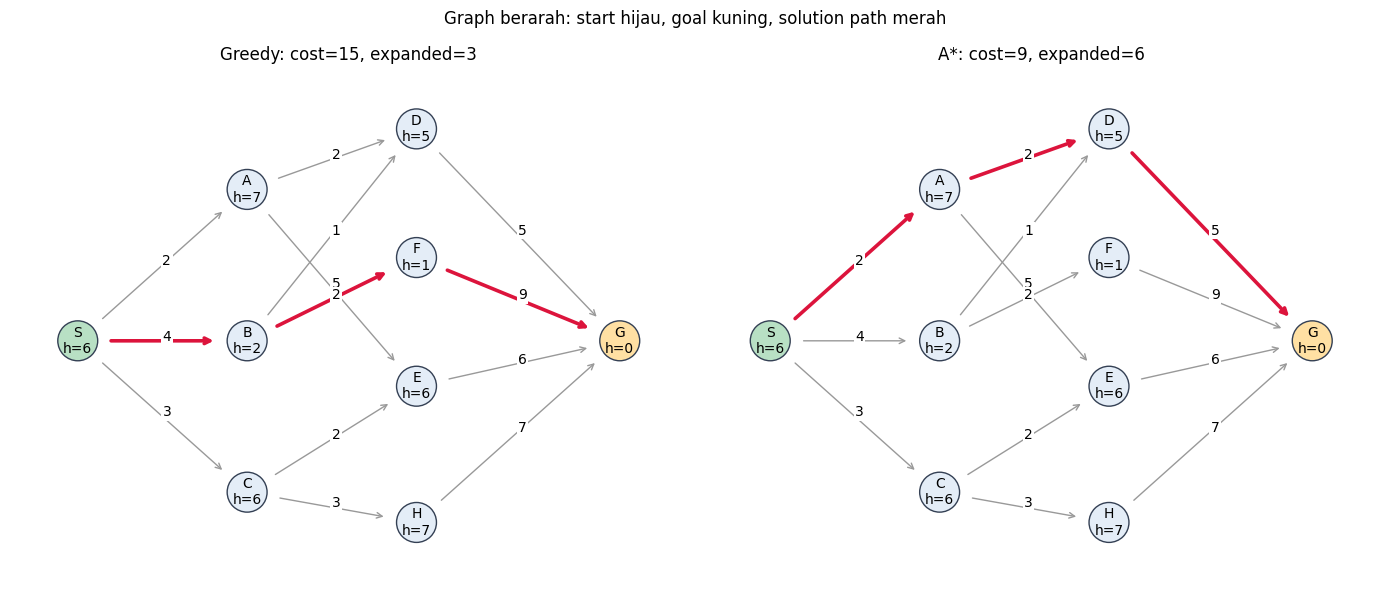

In [30]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib tidak tersedia; gunakan adjacency list dan trace di atas.")
else:
    positions = {
        "S": (0, 1), "A": (1, 2), "B": (1, 1), "C": (1, 0),
        "D": (2, 2.4), "E": (2, 0.7), "F": (2, 1.55),
        "H": (2, -0.2), "G": (3.2, 1),
    }
    figure, axes = plt.subplots(1, 2, figsize=(14, 6))
    for axis, name, result in zip(axes, ["Greedy", "A*"],
                                  [greedy_result, astar_result]):
        solution_edges = set(zip(result["path"], result["path"][1:]))
        for current_state, successors in graph.items():
            for next_state, step_cost in successors:
                current_position = positions[current_state]
                next_position = positions[next_state]
                on_path = (current_state, next_state) in solution_edges
                color = "crimson" if on_path else "#999999"
                axis.annotate("", xy=next_position, xytext=current_position,
                              arrowprops={"arrowstyle": "->", "color": color,
                                          "lw": 2.6 if on_path else 1,
                                          "shrinkA": 24, "shrinkB": 24})
                label_x = (current_position[0] + next_position[0]) / 2
                label_y = (current_position[1] + next_position[1]) / 2
                axis.text(label_x, label_y, str(step_cost), fontsize=10,
                          bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
        for state, position in positions.items():
            color = "#b8e0c4" if state == start else "#e4edf7"
            if state == goal:
                color = "#ffe0a3"
            axis.text(*position, f"{state}\nh={heuristic[state]}", ha="center",
                      va="center", bbox={"boxstyle": "circle,pad=0.35",
                                        "facecolor": color, "edgecolor": "#344054"})
        axis.set_title(f"{name}: cost={result['cost']}, expanded={result['expanded']}")
        axis.set_xlim(-0.4, 3.6)
        axis.set_ylim(-0.6, 2.8)
        axis.axis("off")
    figure.suptitle("Graph berarah: start hijau, goal kuning, solution path merah")
    plt.tight_layout()
    plt.show()

**Perhatikan gambar:** Greedy melalui B dan F, sedangkan A* melalui A dan D.
Node yang terlihat dekat menurut heuristic belum tentu memberi rute termurah dari start.

### c. Sifat algoritma

| Aspek | Greedy | A* |
|---|---|---|
| Priority | h | g+h |
| Biaya sebelumnya memengaruhi priority? | Tidak | Ya |
| Heuristic dipakai? | Ya | Ya |
| Selalu minimum? | Tidak dijamin | Ya, dengan syarat di bawah |
| Menemukan solusi jika ada? | Ya pada graph berhingga dengan penanganan duplicate di sini | Ya pada graph berhingga dengan bobot positif dan heuristic berhingga |

**Optimalitas A\*:** gunakan heuristic admissible, `h(goal)=0`, bobot nonnegatif,
pembaruan biaya dan pembukaan ulang, serta goal test pada pop valid.
Jika state yang sudah diekspansi tidak boleh dibuka ulang, consistency adalah syarat
cukup yang lebih kuat.

**Batas kesimpulan:** contoh kita memakai graph berhingga dan bobot positif.
Pada ruang tak berhingga, Greedy tidak dijamin complete. Kondisi cukup untuk A*
adalah jumlah successor per state berhingga, setiap biaya langkah ≥ epsilon > 0,
heuristic nonnegatif admissible, dan adanya solusi berbiaya berhingga.

Complete berarti menemukan solusi jika ada; optimal berarti cost-nya minimum.
Trace menambah pekerjaan untuk menampilkan frontier, sehingga waktu cetaknya tidak
cocok sebagai ukuran murni kecepatan algoritma.

### d. Hubungan UCS, Greedy, dan A*

| Algoritma | Priority | Fokus |
|---|---|---|
| UCS | $g(n)$ | Biaya yang sudah ditempuh |
| Greedy | $h(n)$ | Estimasi biaya yang tersisa |
| A* | $g(n)+h(n)$ | Estimasi total biaya |

Satu frontier bisa membuat ketiganya memilih node berbeda:

| Node | g | h | f = g+h |
|---|---:|---:|---:|
| A | 1 | 9 | 10 |
| B | 8 | 1 | 9 |
| C | 4 | 3 | 7 |

In [31]:
comparison_frontier = [("A", 1, 9), ("B", 8, 1), ("C", 4, 3)]
for algorithm in ["UCS", "Greedy", "A*"]:
    frontier = []
    for order, (state, current_g, heuristic_value) in enumerate(comparison_frontier):
        if algorithm == "UCS":
            priority = current_g
        elif algorithm == "Greedy":
            priority = heuristic_value
        else:
            priority = current_g + heuristic_value
        heapq.heappush(frontier, (priority, order, state))
    priority, order, state = heapq.heappop(frontier)
    print(f"{algorithm}: pilih {state}, priority={priority}")

UCS: pilih A, priority=1
Greedy: pilih B, priority=1
A*: pilih C, priority=7


**Perhatikan hasil:** UCS memilih A, Greedy memilih B, dan A* memilih C.
Perbedaan rumus priority dapat menghasilkan pilihan berbeda pada frontier yang sama.

## 8. Menerapkan Search pada Grid

Sekarang state berupa posisi `(row, column)`. Aturannya:

- `S`: start, `G`: goal, `#`: obstacle, `.`: sel yang bisa dilalui.
- Gerakan hanya atas, kanan, bawah, dan kiri.
- Setiap langkah berbiaya 1.
- Heuristic menggunakan Manhattan distance.

$$h(n)=|row-row_{goal}|+|column-column_{goal}|.$$

### a. Menyiapkan peta

In [32]:
grid = [
    "S..#.",
    ".#.#.",
    ".#...",
    "..#.G",
]

for line in grid:
    print(" ".join(line))

S . . # .
. # . # .
. # . . .
. . # . G


**Perhatikan peta:** sel bertanda `#` tidak boleh dilewati.

### b. Mengubah grid menjadi graph

Untuk setiap sel yang bisa dilalui, periksa empat tetangganya.
Tambahkan tetangga jika masih berada dalam batas grid dan bukan obstacle.
Dengan bentuk adjacency list ini, fungsi search sebelumnya bisa langsung digunakan.

In [33]:
grid_graph = {}
grid_start = None
grid_goal = None
directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # Atas, kanan, bawah, kiri.

for row in range(len(grid)):
    for column in range(len(grid[0])):
        if grid[row][column] == "#":
            continue
        current_state = (row, column)
        if grid[row][column] == "S":
            grid_start = current_state
        if grid[row][column] == "G":
            grid_goal = current_state
        grid_graph[current_state] = []
        for row_change, column_change in directions:
            next_row = row + row_change
            next_column = column + column_change
            inside = 0 <= next_row < len(grid) and 0 <= next_column < len(grid[0])
            if inside and grid[next_row][next_column] != "#":
                next_state = (next_row, next_column)
                grid_graph[current_state].append((next_state, 1))

grid_heuristic = {}
for state in grid_graph:
    grid_heuristic[state] = manhattan_distance(state, grid_goal)

print("Start:", grid_start, "Goal:", grid_goal)
print("Jumlah state yang dapat dilalui:", len(grid_graph))
print("Successor start:", grid_graph[grid_start])
print("h(start):", grid_heuristic[grid_start])

Start: (0, 0) Goal: (3, 4)
Jumlah state yang dapat dilalui: 15
Successor start: [((0, 1), 1), ((1, 0), 1)]
h(start): 7


**Perhatikan hasil:** start berada di `(0,0)`, goal di `(3,4)`, dan h(start)=7.
Obstacle belum dimasukkan dalam estimasi. Manhattan tetap menjadi batas bawah dan
consistent karena gerakan empat arah berbiaya 1.

### c. Menampilkan path

Fungsi berikut memberi tanda `*` pada sel yang dilalui, tanpa mengubah S dan G.

In [34]:
def show_grid(grid, path):
    path_states = set(path)
    for row in range(len(grid)):
        symbols = []
        for column in range(len(grid[0])):
            symbol = grid[row][column]
            if (row, column) in path_states and symbol == ".":
                symbol = "*"
            symbols.append(symbol)
        print(" ".join(symbols))

### d. Menjalankan algoritma yang sama

Kita hanya mengganti data graph dan heuristic. Kode Greedy dan A* tidak perlu diubah.

In [35]:
grid_greedy = greedy_search(grid_graph, grid_start, grid_goal, grid_heuristic)
grid_astar = a_star_search(grid_graph, grid_start, grid_goal, grid_heuristic)
for name, result in [("Greedy", grid_greedy), ("A*", grid_astar)]:
    print(f"{name}: cost={result['cost']}, expanded={result['expanded']}")
print("\nPath A*:", grid_astar["path"])
show_grid(grid, grid_astar["path"])
print("\nTiga pemilihan awal A*:")
print_trace(grid_astar["trace"][:3], "A*")

Greedy: cost=7, expanded=7
A*: cost=7, expanded=12

Path A*: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4)]
S * * # .
. # * # .
. # * * *
. . # . G

Tiga pemilihan awal A*:


| Iterasi | Dipilih | g | h | f | Aksi | Frontier sesudah |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | (0, 0) | 0 | 7 | 7 | expand | (0, 1)(g=1,h=6,f=7); (1, 0)(g=1,h=6,f=7) |
| 2 | (0, 1) | 1 | 6 | 7 | expand | (1, 0)(g=1,h=6,f=7); (0, 2)(g=2,h=5,f=7) |
| 3 | (1, 0) | 1 | 6 | 7 | expand | (0, 2)(g=2,h=5,f=7); (2, 0)(g=2,h=5,f=7) |

**Perhatikan hasil:** A* menemukan path berbiaya 7, berarti ada 7 perpindahan legal.
Greedy juga mendapat cost 7 pada grid ini. Greedy bisa memperoleh hasil optimal pada
suatu contoh meskipun tidak dijamin optimal secara umum.

**Coba pikirkan:** jika satu sel pada path menjadi obstacle, apakah estimasi Manhattan
harus memasukkan obstacle tersebut agar tetap menjadi batas bawah?

### e. Membaca perubahan g, h, dan f pada grid

Gunakan path A* yang baru diperoleh untuk menghubungkan posisi dengan nilai biaya.
Karena setiap langkah berbiaya 1, biaya `g` sepanjang path ini bertambah satu
pada setiap perpindahan. Nilai `h` dihitung dari posisi saat ini menuju goal,
dan `f` merupakan jumlah keduanya.

**Prediksi:** bagaimana nilai h berubah ketika bergerak satu langkah mendekati goal?
Bagaimana jika rute harus bergerak menjauhi goal untuk menghindari obstacle?

In [36]:
grid_path_rows = []
for path_cost, position in enumerate(grid_astar["path"]):
    estimate = grid_heuristic[position]
    grid_path_rows.append([position, path_cost, estimate, path_cost + estimate])

show_table(["Posisi", "g pada path", "h Manhattan", "f = g+h"], grid_path_rows)
print("Pelanggaran consistency pada grid:",
      consistency_violations(grid_graph, grid_heuristic))

| Posisi | g pada path | h Manhattan | f = g+h |
| --- | --- | --- | --- |
| (0, 0) | 0 | 7 | 7 |
| (0, 1) | 1 | 6 | 7 |
| (0, 2) | 2 | 5 | 7 |
| (1, 2) | 3 | 4 | 7 |
| (2, 2) | 4 | 3 | 7 |
| (2, 3) | 5 | 2 | 7 |
| (2, 4) | 6 | 1 | 7 |
| (3, 4) | 7 | 0 | 7 |

Pelanggaran consistency pada grid: []


**Perhatikan hasil:** pada path contoh, g naik dari 0 sampai 7, sedangkan h turun
dari 7 sampai 0. Nilai f tetap 7 karena setiap langkah pada path ini mendekati goal.
Tabel ini menampilkan **path solusi**, sedangkan trace sebelumnya menampilkan
**urutan pemilihan dari frontier**; keduanya dapat memuat state yang berbeda.

Daftar pelanggaran consistency kosong: setiap edge memenuhi
`h(current) ≤ 1 + h(next)`. Gerakan yang menjauhi goal dapat menaikkan h,
tetapi tetap memenuhi syarat tersebut pada grid empat arah berbiaya 1.

**Diskusi:** mengapa h tidak perlu memasukkan obstacle agar tetap menjadi batas bawah?

## 9. Eksperimen Heuristic

### a. Membentuk heuristic dari masalah yang lebih mudah

Bayangkan dinding pada grid dihapus. Perjalanan tidak menjadi lebih sulit, sehingga
biaya minimum tanpa dinding menjadi batas bawah biaya dengan dinding.
Ini disebut **relaxation**; Manhattan memakai gagasan tersebut pada grid empat arah.

Jika dua heuristic admissible memenuhi $h_2(n)\ge h_1(n)$ untuk semua state,
`h2` **mendominasi** `h1`: batas bawahnya setidaknya sama informatif.
`max(h1,h2)` juga admissible. Jumlah `h1+h2` belum tentu admissible.
Contoh berikut membandingkan kedua cara menggabungkan estimasi tersebut.

In [37]:
current_position = (1, 2)
target_position = (4, 6)
h_euclidean = euclidean_distance(current_position, target_position)
h_manhattan = manhattan_distance(current_position, target_position)
print("Euclidean:", h_euclidean)
print("Manhattan:", h_manhattan)
print("Max:", max(h_euclidean, h_manhattan))
print("Jumlah:", h_euclidean + h_manhattan)

Euclidean: 5.0
Manhattan: 7
Max: 7
Jumlah: 12.0


**Perhatikan hasil:** max=7 tetap batas bawah, tetapi jumlah=12 melebihi rute
terpendek 7 langkah pada grid kosong. Pada grid empat arah cost 1, Manhattan
mendominasi Euclidean. Hasil satu posisi saja bukan bukti dominasi seluruh state;
alasannya adalah jarak lurus selalu tidak melebihi jumlah jarak kedua sumbu.

Dominasi tidak berarti setiap run pasti memiliki jumlah ekspansi lebih kecil:
tie, pembukaan ulang, dan biaya menghitung heuristic perlu diperhatikan.
Dalam tugas, uji perubahan heuristic sambil memeriksa apakah sifatnya tetap valid.

### b. Membandingkan tiga pilihan heuristic

Gunakan graph utama dan tie-breaking yang sama agar perbandingannya adil.

In [38]:
zero_heuristic = {}
for state in graph:
    zero_heuristic[state] = null_heuristic(state)

overestimating_heuristic = heuristic.copy()
overestimating_heuristic["A"] = 50

experiment_results = {}
rows = []
for label, estimates in [("Null / UCS", zero_heuristic),
                         ("Informatif", heuristic),
                         ("h(A)=50", overestimating_heuristic)]:
    result = a_star_search(graph, start, goal, estimates)
    experiment_results[label] = result
    rows.append([label, result["cost"], result["expanded"],
                 " → ".join(result["path"]), " → ".join(result["expansion_order"])])
show_table(["Heuristic", "Cost", "Ekspansi", "Path", "Urutan ekspansi"], rows)

| Heuristic | Cost | Ekspansi | Path | Urutan ekspansi |
| --- | --- | --- | --- | --- |
| Null / UCS | 9 | 8 | S → A → D → G | S → A → C → B → D → E → H → F |
| Informatif | 9 | 6 | S → A → D → G | S → B → F → A → C → D |
| h(A)=50 | 10 | 5 | S → B → D → G | S → B → F → C → D |

**Perhatikan hasil:**

- Null heuristic: cost 9, dengan 8 ekspansi.
- Heuristic awal: cost tetap 9, dengan 6 ekspansi.
- h(A)=50: cost naik menjadi 10; rute optimal melalui A terlewat.

Heuristic yang informatif dapat mengurangi usaha pencarian. Namun, nilai lebih besar
tidak otomatis lebih baik: `h(A)=50` melebihi biaya minimum sebenarnya, yaitu 7.
Jumlah ekspansi juga dipengaruhi tie, struktur graph, dan pembukaan ulang state.

**Coba sendiri:** buat salinan heuristic, ubah satu nilai, lalu jalankan A* lagi.
Jelaskan perubahan hasil menggunakan f pada trace.

## 10. Menguji Program sebelum Mengerjakan Tugas

Gunakan contoh berhasil, start=goal, goal tidak terjangkau, cycle, stale, dan reopen.
Semua assertion berikut harus lolos. Tugas menyediakan pengujian serupa dengan graph
mini, sehingga Anda dapat memperbaiki implementasi sebelum memakai graph 14 state.

In [39]:
for search_function in [greedy_search, a_star_search]:
    same_result = search_function(graph, "S", "S", zero_heuristic)
    assert same_result["path"] == ["S"]
    assert same_result["cost"] == 0
    assert same_result["expanded"] == 0

    disconnected_graph = {"S": [("A", 1)], "A": [("S", 1)], "G": []}
    disconnected_h = {"S": 0, "A": 0, "G": 0}
    missing_result = search_function(disconnected_graph, "S", "G", disconnected_h)
    assert missing_result["path"] == []
    assert missing_result["cost"] == float("inf")
    assert missing_result["expanded"] == 2

assert greedy_result["cost"] == 15
assert astar_result["cost"] == 9
assert experiment_results["Null / UCS"]["cost"] == astar_result["cost"]
assert stale_result["skipped"] == [("A", 5, 2)]
assert reopen_result["cost"] == 6
assert reopen_result["expansion_order"] == ["S", "A", "B", "A"]
print("Pemeriksaan contoh, start=goal, unreachable, cycle, stale, dan reopen: lulus.")

Pemeriksaan contoh, start=goal, unreachable, cycle, stale, dan reopen: lulus.


## 11. Ringkasan dan Persiapan Tugas

### a. Ringkasan

| Algoritma / konsep | Yang perlu diingat |
|---|---|
| UCS | Priority = g(n) |
| Greedy | Priority = h(n) |
| A* | Priority = g(n) + h(n) |
| g(n) | Biaya nyata path yang diketahui dari start |
| h(n) | Estimasi biaya minimum tersisa menuju goal |
| f(n) | Fungsi evaluasi; untuk A* nilainya g+h |
| Admissible | h(n) ≤ h*(n) |
| Consistent | h(n) ≤ c(n,n') + h(n') pada setiap edge |
| Parent | Menyimpan asal state untuk menyusun path |

Greedy berfokus pada perkiraan sisa biaya. A* mempertimbangkan biaya yang sudah
ditempuh dan memperbaruinya ketika ditemukan jalur lebih murah.

### b. Latihan pemahaman

1. Frontier berisi `A: g=3,h=7`, `B: g=5,h=3`, dan `C: g=2,h=8`.
   Pilihan mana yang diambil Greedy, A*, dan UCS? Sertakan perhitungannya.
2. Apa yang terjadi pada A* jika semua h=0?
3. Mengapa heuristic admissible tidak menjamin hasil Greedy optimal?
4. Mengapa parent harus diperbarui ketika g membaik pada A*?
5. Mengapa goal diuji saat di-pop dan tidak dihitung sebagai ekspansi?
6. Jika `h(P)=6`, `c(P,Q)=2`, dan `h(Q)=3`, apakah edge ini consistent?
7. Mengapa lebih sedikit ekspansi belum tentu menghasilkan path lebih murah?

Tuliskan jawaban sebelum berdiskusi. Lanjutkan tugas di `02_tugas_individu.ipynb`.

## Sources:
[inst.eecs.berkeley.edu](https://inst.eecs.berkeley.edu/~cs188/textbook/search/informed.html)